# 📘 Risk Analysis — Winter Semester 2025/2026
## Tutorial 6: Extreme Value Distributions

**Supervisor:** Dr. Daniel Straub  
**Conducted by:** Milad Cheraghzade  
**Date:** December 4th, 2025  
**Time:** 15:00–16:00  
**Location:** TUM, Room N 1070  

---


## Problem 1


===== CDF Comparison =====
   x      Analytical     Numerical
 90.0      0.000000      0.000000
 92.0      0.028000      0.028000
 95.0      0.156250      0.156250
100.0      0.500000      0.500000
105.0      0.843750      0.843750
110.0      1.000000      1.000000

P(Y ≤ 92) = 0.2472293996581829


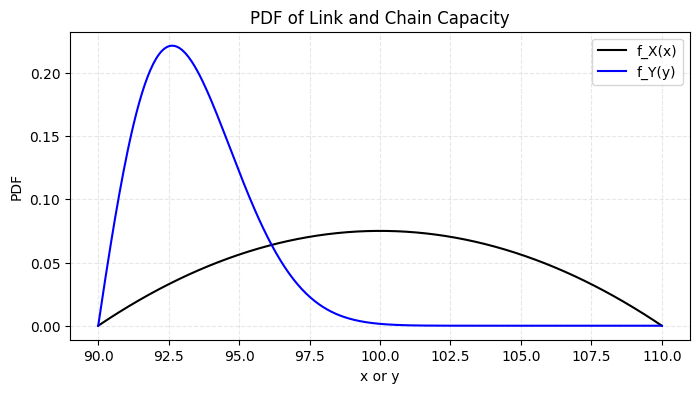

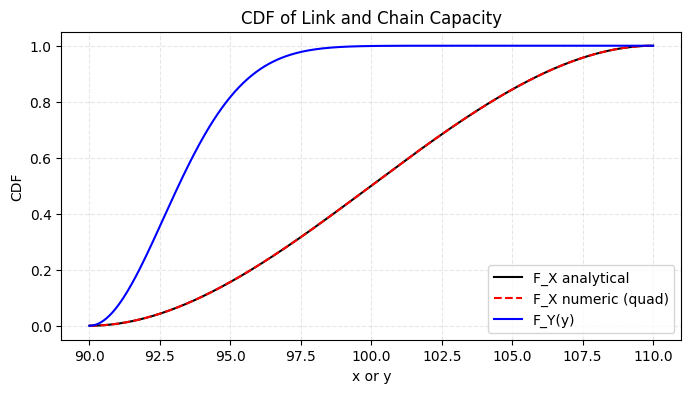

In [ ]:
# =====================================================
# Problem 1 – Chain Capacity 
# =====================================================
# Each link:
#    f_X(x) = (3/4000)*(x - 90)*(110 - x),  90 ≤ x ≤ 110
#
# Chain capacity:
#    Y = min(X1, ..., X10)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -----------------------------------------------------
# PDF of link
# -----------------------------------------------------
def f_X(x):
    return np.where(
        (x >= 90) & (x <= 110),
        (3/4000)*(x - 90)*(110 - x),
        0.0
    )

# -----------------------------------------------------
# Analytical CDF (derived earlier)
# -----------------------------------------------------
def F_X_analytical(x):
    val = 243 + (3/4000)*(-x**3/3 + 100*x**2 - 9900*x)
    return np.clip(val, 0, 1)

# -----------------------------------------------------
# Numerical CDF using exact integration (quad)
# -----------------------------------------------------
def F_X_numeric(x):

    # scalar input
    if np.isscalar(x):
        if x <= 90:
            return 0.0
        if x >= 110:
            return 1.0
        val, err = quad(f_X, 90, x)
        return val

    # vector input
    x = np.asarray(x)
    results = np.zeros_like(x, dtype=float)

    for i, xi in enumerate(x):
        if xi <= 90:
            results[i] = 0.0
        elif xi >= 110:
            results[i] = 1.0
        else:
            results[i], _ = quad(f_X, 90, xi)

    return results

# -----------------------------------------------------
# Minimum of n=10 links
# -----------------------------------------------------
n = 10

def F_Y(y):
    return 1 - (1 - F_X_analytical(y))**n

def f_Y(y):
    return n * f_X(y) * (1 - F_X_analytical(y))**(n - 1)

# -----------------------------------------------------
# Compare analytical vs numerical CDF
# -----------------------------------------------------
test_points = [90, 92, 95, 100, 105, 110]

print("\n===== CDF Comparison =====")
print("   x      Analytical     Numerical")
for x in test_points:
    Fa = F_X_analytical(x)
    Fn = F_X_numeric(x)
    print(f"{x:5.1f}    {Fa:10.6f}    {Fn:10.6f}")

# Example probability
print("\nP(Y ≤ 92) =", F_Y(92))

# -----------------------------------------------------
# Plot PDF
# -----------------------------------------------------
x = np.linspace(90, 110, 400)
plt.figure(figsize=(8,4))
plt.plot(x, f_X(x), 'k-', label='f_X(x)')
plt.plot(x, f_Y(x), 'b-', label='f_Y(y)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel("x or y")
plt.ylabel("PDF")
plt.title("PDF of Link and Chain Capacity")
plt.legend()
plt.show()

# -----------------------------------------------------
# Plot CDF (analytical vs numerical)
# -----------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(x, F_X_analytical(x), 'k-', label='F_X analytical')
plt.plot(x, F_X_numeric(x), 'r--', label='F_X numeric (quad)')
plt.plot(x, F_Y(x), 'b-', label='F_Y(y)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel("x or y")
plt.ylabel("CDF")
plt.title("CDF of Link and Chain Capacity")
plt.legend()
plt.show()



===== CDF Comparison (10-year max) =====
   s     Analytical      MC estimate
 40.0        0.00180        0.00181
 50.0        0.04605        0.04675
 60.0        0.28202        0.28174
 70.0        0.61528        0.61554
 80.0        0.83403        0.83454
100.0        0.97555        0.97562


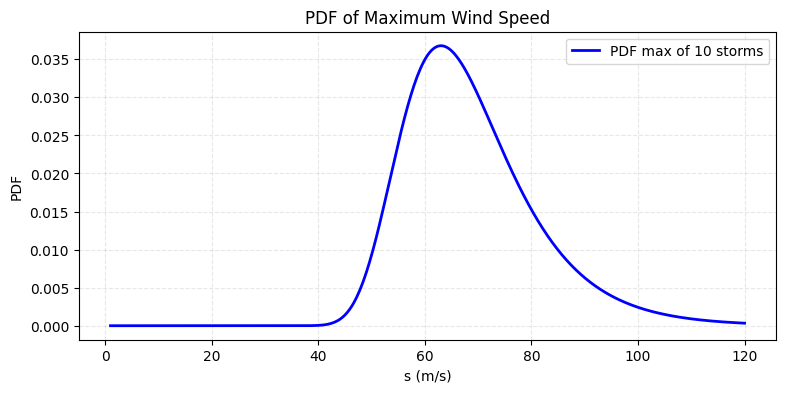

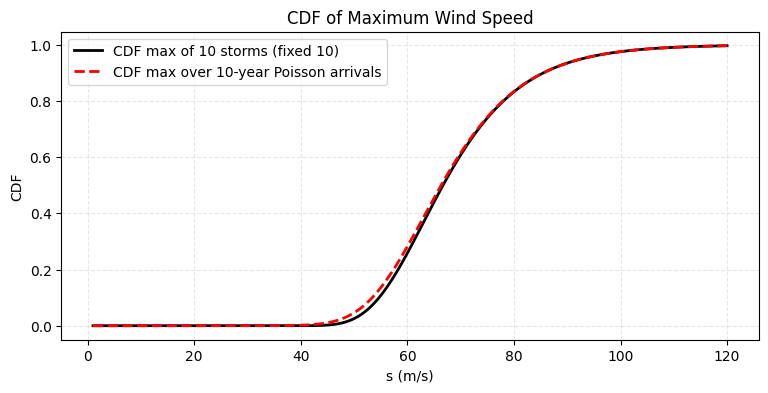

In [1]:
# =====================================================
# Problem – Maximum Wind Speed (Corrected & Final)
# =====================================================
# Each storm:
#   X ~ Gumbel(a=10, b=40)
#
# Part (1): M10 = max(X1,...,X10)
# Part (2): storms arrive as N ~ Poisson(10)
#           compute the CDF of the maximum using
#           conditional distribution + total probability
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

# -----------------------------------------------------
# Gumbel PDF and CDF
# -----------------------------------------------------
a = 10       # scale
b = 40       # location

def F_X(x):
    return np.exp(-np.exp(-(x - b)/a))

def f_X(x):
    return (1/a)*np.exp(-(x - b)/a - np.exp(-(x - b)/a))


# -----------------------------------------------------
# Part (1): Maximum of 10 storms (max-stability)
# -----------------------------------------------------
n = 10
b10 = b + a*np.log(n)   # shifted Gumbel location
a10 = a                 # same scale

def F_M10(s):
    return np.exp(-np.exp(-(s - b10)/a10))

def f_M10(s):
    return (1/a10)*np.exp(-(s - b10)/a10 - np.exp(-(s - b10)/a10))


# -----------------------------------------------------
# Part (2): Maximum over 10 years (Poisson arrivals)
#           Use total probability: 
#           F(s) = Σ F(s|n) * P(N=n)
# -----------------------------------------------------
lambda_rate = 1     # storms per year
t_years = 10
lam = lambda_rate * t_years

def p_n(n):
    return (lam**n / factorial(n)) * np.exp(-lam)

def F_cond(s, n):
    if n == 0:
        return 1.0     # no storms -> max = -∞, so P(S ≤ s) = 1
    b_n = b + a*np.log(n)
    return np.exp(-np.exp(-(s - b_n)/a))

max_n = 200  # truncation (very accurate)

def F_M10yr(s):
    total = 0.0
    for n in range(0, max_n + 1):
        total += F_cond(s, n) * p_n(n)
    return total


# -----------------------------------------------------
# Monte Carlo simulation for validation
# -----------------------------------------------------
Nsim = 200000

# Simulate number of storms in 10 years
N = np.random.poisson(10, size=Nsim)

M10yr_sim = np.zeros(Nsim)

for i in range(Nsim):
    if N[i] == 0:
        M10yr_sim[i] = -np.inf
    else:
        storms = b - a*np.log(-np.log(np.random.rand(N[i])))
        M10yr_sim[i] = np.max(storms)


# -----------------------------------------------------
# Compare analytical vs Monte Carlo
# -----------------------------------------------------
test_points = [40, 50, 60, 70, 80, 100]

print("\n===== CDF Comparison (10-year max) =====")
print("   s     Analytical      MC estimate")
for s in test_points:
    Fa = F_M10yr(s)
    Fmc = np.mean(M10yr_sim <= s)
    print(f"{s:5.1f}   {Fa:12.5f}   {Fmc:12.5f}")


# -----------------------------------------------------
# Plot PDF / CDF
# -----------------------------------------------------
s = np.linspace(1, 120, 400)

plt.figure(figsize=(9,4))
plt.plot(s, f_M10(s), 'b-', lw=2, label='PDF max of 10 storms')
plt.grid(alpha=0.3, linestyle='--')
plt.xlabel("s (m/s)")
plt.ylabel("PDF")
plt.title("PDF of Maximum Wind Speed")
plt.legend()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(s, F_M10(s), 'k-', lw=2, label='CDF max of 10 storms (fixed 10)')
plt.plot(s, [F_M10yr(x) for x in s], 'r--', lw=2, 
         label='CDF max over 10-year Poisson arrivals')
plt.grid(alpha=0.3, linestyle='--')
plt.xlabel("s (m/s)")
plt.ylabel("CDF")
plt.title("CDF of Maximum Wind Speed")
plt.legend()
plt.show()


## Problem 3


===== Earthquake Probability Results =====
P(M1 < 6) = F_M(6) = 0.864665
P(Y10 < 6) = 0.233602
P(M11 > Y10) = 0.090909


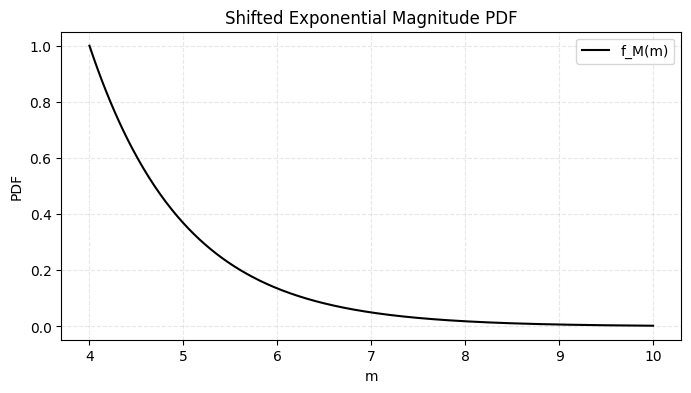

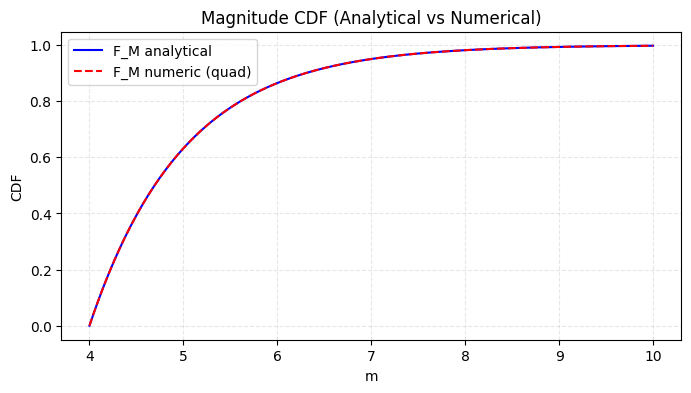

In [7]:
# =====================================================
# Problem – Earthquake Magnitudes
# =====================================================
# Magnitudes follow a shifted exponential:
#     f_M(m) = exp(-(m-4)),   m >= 4
#
# Independent magnitudes:
#     M1, ..., M10
#
# Goal:
#   (1) Compute P(Y10 < 6) where Y10 = max(M1...M10)
#   (2) Compute P(M11 > Y10)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -----------------------------------------------------
# PDF of magnitude
# -----------------------------------------------------
def f_M(m):
    return np.where(m >= 4, np.exp(-(m - 4)), 0.0)

# -----------------------------------------------------
# Analytical CDF
# F_M(m) = 1 - exp(-(m-4)), m>=4
# -----------------------------------------------------
def F_M_analytical(m):
    m = np.asarray(m)
    F = np.zeros_like(m, dtype=float)
    mask = (m >= 4)
    F[mask] = 1 - np.exp(-(m[mask] - 4))
    F[m >= 1e6] = 1.0  # safety
    return F

# -----------------------------------------------------
# Numerical CDF using quad
# -----------------------------------------------------
def F_M_numeric(m):

    # scalar
    if np.isscalar(m):
        if m < 4:
            return 0.0
        val, _ = quad(lambda x: np.exp(-(x - 4)), 4, m)
        return val

    # vector input
    m = np.asarray(m)
    out = np.zeros_like(m, dtype=float)

    for i, mi in enumerate(m):
        if mi < 4:
            out[i] = 0.0
        else:
            out[i], _ = quad(lambda x: np.exp(-(x - 4)), 4, mi)

    return out

# -----------------------------------------------------
# Maximum of first 10 magnitudes
# -----------------------------------------------------
n = 10

def P_Y10_less_than(m):
    return (F_M_analytical(m))**n

# -----------------------------------------------------
# Main probabilities
# -----------------------------------------------------
# (1) P(Y10 < 6)
P_Y10 = P_Y10_less_than(6)

# (2) P(M11 > Y10)
def integrand(m):
    return (F_M_analytical(m)**10) * f_M(m)

P_M11 = quad(lambda m: integrand(m), 4, np.inf)[0]

# -----------------------------------------------------
# Print results
# -----------------------------------------------------
print("\n===== Earthquake Probability Results =====")
print(f"P(M1 < 6) = F_M(6) = {F_M_analytical(6):.6f}")
print(f"P(Y10 < 6) = {P_Y10:.6f}")
print(f"P(M11 > Y10) = {P_M11:.6f}")

# -----------------------------------------------------
# Plot PDF
# -----------------------------------------------------
m_vals = np.linspace(4, 10, 400)
plt.figure(figsize=(8,4))
plt.plot(m_vals, f_M(m_vals), 'k-', label='f_M(m)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel("m")
plt.ylabel("PDF")
plt.title("Shifted Exponential Magnitude PDF")
plt.legend()
plt.show()

# -----------------------------------------------------
# Plot CDF (analytical vs numerical)
# -----------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(m_vals, F_M_analytical(m_vals), 'b-', label='F_M analytical')
plt.plot(m_vals, F_M_numeric(m_vals), 'r--', label='F_M numeric (quad)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel("m")
plt.ylabel("CDF")
plt.title("Magnitude CDF (Analytical vs Numerical)")
plt.legend()
plt.show()
